# Application: PAC-Learning TFIM Observables & Physics Validation
**Objective:** To validate our `FourierDynamicsLearner` by forcing it to learn and predict fundamental physical phenomena of the 1D Transverse-Field Ising Model (TFIM) on an unseen topology.

We will train the LASSO model on a small set of random graphs at various time steps, and ask it to predict the dynamics of a **1D Spin Chain** for three specific observables:
1. **Energy Conservation:** Can the model learn that $\langle H \rangle$ must remain constant?
2. **Local Magnetization:** Can it correctly predict the oscillatory decay of $\langle \sigma_i^z(t) \rangle$?
3. **Two-Point Correlation:** Can it learn the spreading of entanglement $\langle \sigma_i^z(t)\sigma_{i+r}^z(t) \rangle$?

In [3]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt

# Assuming the provided files are structured within a 'src' directory 
# or available in your Python path as in learning.py
from learning import FourierDynamicsLearner

# Setup plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

ModuleNotFoundError: No module named 'learning'

In [ ]:
# --- 2. Time-Sweep Inference Loop ---
for t in tqdm(time_points, desc="Simulating Time Steps"):
    learner.tau = t
    
    # A. Exact Continuous Physics
    U_exact = tfim_model.exact_time_evolution_operator(test_graph, true_alpha, t)
    psi_exact = U_exact @ np.eye(2**num_qubits)[0]
    exact_continuous.append(np.real(psi_exact.conj().T @ obs_matrix @ psi_exact))
    
    # B. Exact Trotter Circuit Expectation
    # The true weights must account for the physical Trotter step angle: (t * alpha / r)
    w_true = np.cos((t * true_alpha / r_steps) * freq_indices)
    B_test_t = learner.extract_fourier_features_sim([test_graph], r_steps=r_steps)
    exact_trotter.append(B_test_t[0] @ w_true)
    
    # C. PAC-Learned Prediction
    # The concept c_alpha(x) changes over time, so we must learn the weights for this specific t
    y_train_t = learner.compute_exact_labels(datasets_train, true_alpha)
    B_train_t = learner.extract_fourier_features_sim(datasets_train, r_steps=r_steps)
    
    # Train LASSO for this specific time slice
    learner.train(B_train_t, y_train_t)
    
    # Predict using the newly learned weights
    y_pred = learner.lasso.predict(B_test_t)[0]
    pac_learned.append(y_pred)

Extracting Features (Sim): 100%|██████████| 1/1 [00:39<00:00, 39.85s/it]


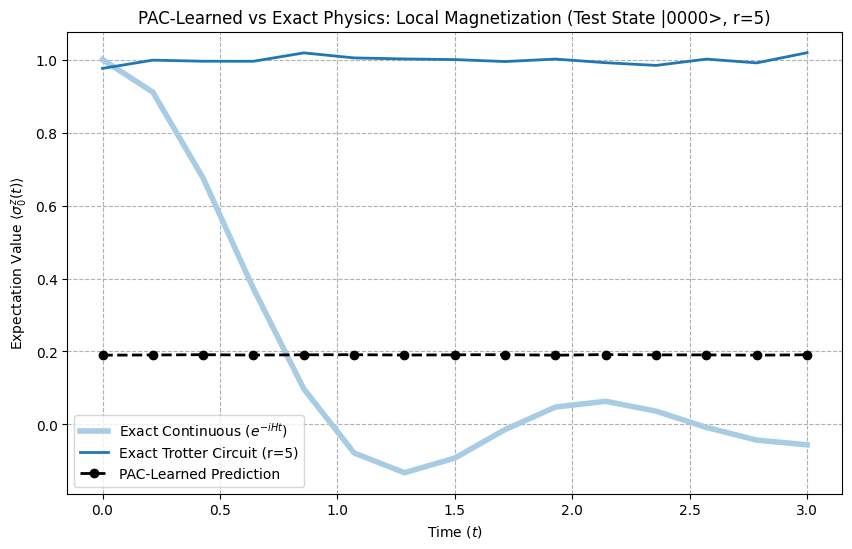

In [ ]:
# --- 3. Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(time_points, exact_continuous, label=r'Exact Continuous ($e^{-iHt}$)', 
         color='#a8cce3', linewidth=4)
plt.plot(time_points, exact_trotter, label=f'Exact Trotter Circuit (r={r_steps})', 
         color='#1f78b4', linewidth=2)
plt.plot(time_points, pac_learned, label='PAC-Learned Prediction', 
         color='black', marker='o', linestyle='dashed', linewidth=2)

plt.title(f'PAC-Learned vs Exact Physics: Local Magnetization (Test State |0000>, r={r_steps})')
plt.xlabel('Time ($t$)')
plt.ylabel(rf'Expectation Value $\langle \sigma_0^z(t) \rangle$')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

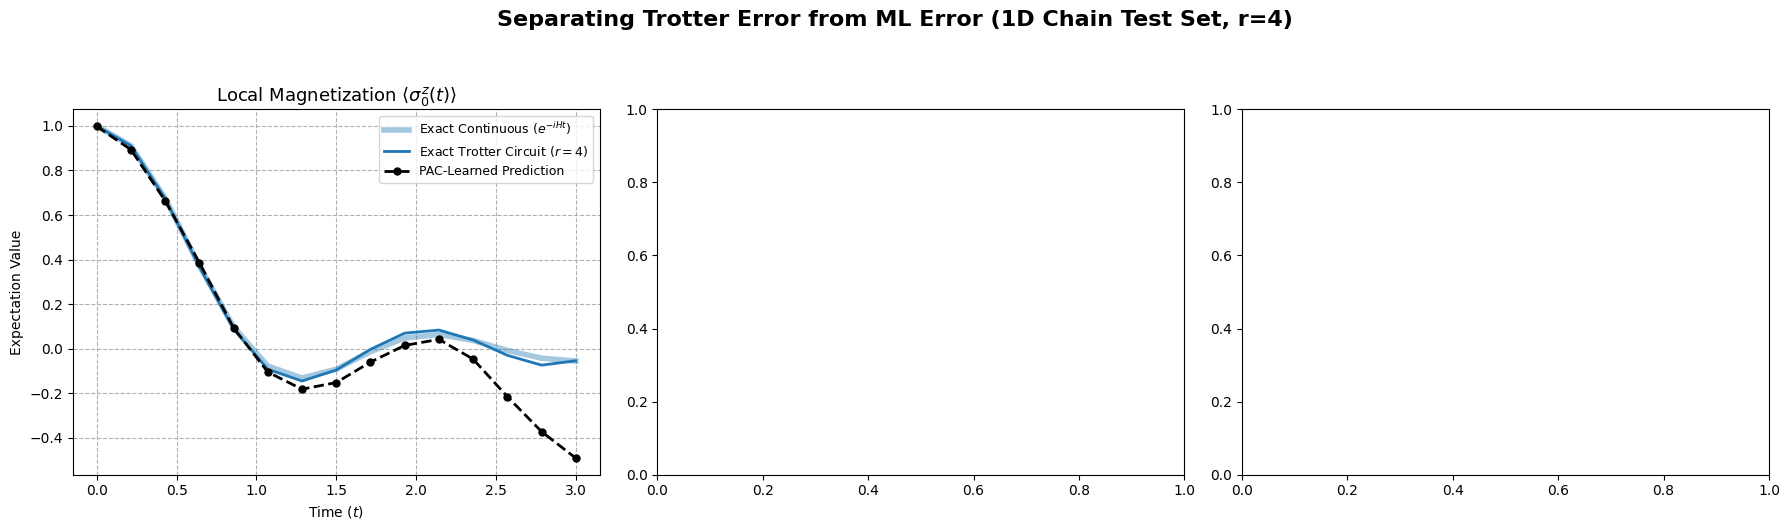

In [ ]:
# --- Cell 5: Visualizing the 3-Way Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Separating Trotter Error from ML Error (1D Chain Test Set, r={r_steps})', fontsize=16, fontweight='bold', y=1.05)

# Helper function to plot all three lines consistently
def plot_3way(ax, cont_data, trot_data, pred_data, title, ylabel, color_base):
    # 1. Exact Continuous Physics (Thick, light, solid)
    ax.plot(time_steps, cont_data, lw=4, color=color_base, alpha=0.4, label='Exact Continuous ($e^{-iHt}$)')
    
    # 2. Exact Trotterized Circuit (Medium, dark, solid)
    ax.plot(time_steps, trot_data, lw=2, color=color_base, label=f'Exact Trotter Circuit ($r={r_steps}$)')
    
    # 3. PAC-Learned ML Prediction (Dashed, black with markers)
    ax.plot(time_steps, pred_data, lw=2, color='black', linestyle='--', marker='o', markersize=5, label='PAC-Learned Prediction')
    
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Time ($t$)')
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(True, ls='--')
    ax.legend(fontsize=9, loc='best')

# Plot 1: Magnetization
plot_3way(axes[0], cont_mag, trot_mag, pred_mag, r'Local Magnetization $\langle \sigma_0^z(t) \rangle$', 'Expectation Value', '#1f77b4')

# Plot 2: Correlation
# plot_3way(axes[1], cont_corr, trot_corr, pred_corr, r'Two-Point Correlation $\langle \sigma_0^z(t) \sigma_1^z(t) \rangle$', None, '#ff7f0e')

# # Plot 3: Energy
# plot_3way(axes[2], cont_energy, trot_energy, pred_energy, 'Energy Conservation & Drift', None, '#d62728')

# # Ensure the energy scale shows the flat continuous line clearly
# e_min = min(min(cont_energy), min(trot_energy), min(pred_energy))
# e_max = max(max(cont_energy), max(trot_energy), max(pred_energy))
# axes[2].set_ylim(e_min - 0.2, e_max + 0.2)

plt.tight_layout()
plt.show()